In [ ]:
from _wine_data import load_wine_quality
  
# load dataset from the local wine+quality (1) directory
wine_quality = load_wine_quality()
  
# data (as pandas dataframes) 
x = wine_quality.data.features 
y = wine_quality.data.targets 
  
# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 

In [ ]:
from _wine_data import load_wine_quality
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

wine_quality = load_wine_quality()
X = wine_quality.data.features
y = wine_quality.data.targets

df = pd.concat([X, y], axis=1)

# 1. histogram
df.hist(figsize=(12, 10), bins=20)
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

# 2. bar plot - relationships with target
important = ['alcohol', 'volatile_acidity', 'sulphates', 'density']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i, feature in enumerate(important):
    df.groupby('quality')[feature].mean().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Average {feature} by Quality')
    axes[i].set_xlabel('quality')
    axes[i].set_ylabel(feature)
plt.suptitle('Feature Relationships with Target')
# just for density, zoom in on the y axis
df.groupby('quality')['density'].mean().plot(kind='bar')
plt.title('Average Density by Quality')
plt.ylim(0.99, 1.00)  # zoom in
plt.show()
plt.tight_layout()
plt.show()

# 3. correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Cluster profile (means):
          alcohol  volatile_acidity  sulphates  density  quality
cluster                                                        
0          10.24              0.57       0.66     1.00     5.53
1          11.69              0.28       0.49     0.99     6.25
2           9.60              0.27       0.49     1.00     5.60


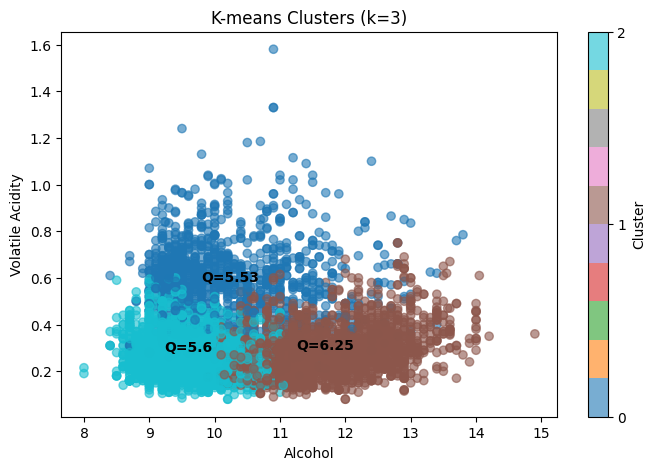

In [ ]:
# Import libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Fill missing values
df.fillna(df.median(), inplace=True)

# Use the 4 features from your EDA
features = ['alcohol', 'volatile_acidity', 'sulphates', 'density']
X_km = df[features]

# Scale the features
scaler = StandardScaler()
X_km_scaled = scaler.fit_transform(X_km)

# Fit K-means with k=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_km_scaled)

# Profile the clusters (including quality)
profile = df.groupby('cluster')[['alcohol', 'volatile_acidity', 'sulphates', 'density', 'quality']].mean().round(2)
print("Cluster profile (means):\n", profile)

# ---- Option 2: Visualize with clusters (color) ----
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df['alcohol'], df['volatile_acidity'],
                      c=df['cluster'], cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Cluster', ticks=[0, 1, 2])
plt.xlabel('Alcohol')
plt.ylabel('Volatile Acidity')
plt.title('K-means Clusters (k=3)')

for cluster_id, row in profile.iterrows():
    plt.text(row['alcohol'], row['volatile_acidity'],
             f"Q={row['quality']}", fontsize=10, fontweight='bold', 
             ha='center', va='bottom', color='black')

plt.show()

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Three quality buckets: bad (<5), medium ([5,7)), good (>=7)
y_bucket = np.select(
    [
        df["quality"].values < 5,
        (df["quality"].values >= 5) & (df["quality"].values < 7),
        df["quality"].values >= 7,
    ],
    [0, 1, 2],
    default=-1,
)

feature_cols = [
    "fixed_acidity",
    "volatile_acidity",
    "citric_acid",
    "residual_sugar",
    "chlorides",
    "free_sulfur_dioxide",
    "total_sulfur_dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
]
X = df[feature_cols]

# 60% train / 20% validation / 20% test
X_temp, X_test_unused, y_temp, y_test_unused = train_test_split(
    X,
    y_bucket,
    test_size=0.2,
    random_state=42,
    stratify=y_bucket,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp,
)

X_train = np.asarray(X_train, dtype=float)
X_val = np.asarray(X_val, dtype=float)

k_values = [1, 3, 5, 7, 9, 11]
# choose these odd values to prevent ties and i wanted 6 evenly spaced off values from very local/ flexible to a more structured/smooth model by the end which would test high bias/low variance ( stopped at 11 because there were only 10 features)

# Baseline: original features + StandardScaler (preprocessing)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

knn_results = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights="uniform")
    knn.fit(X_train_scaled, y_train)
    knn_results.append(
        {
            "k": k,
            "train_acc": knn.score(X_train_scaled, y_train),
            "val_acc": knn.score(X_val_scaled, y_val),
        }
    )

# Polynomial degree 2: squared, then scale for KNN. Degree 2 addssquares and is a more complex model class, I wanted to test it out to see if pattern was better than the linear one
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

scaler_poly = StandardScaler()
X_train_poly2_scaled = scaler_poly.fit_transform(X_train_poly)
X_val_poly2_scaled = scaler_poly.transform(X_val_poly)

knn_results_poly = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_poly2_scaled, y_train)
    knn_results_poly.append(
        {
            "k": k,"train_acc": knn.score(X_train_poly2_scaled, y_train),"val_acc": knn.score(X_val_poly2_scaled, y_val),
        }
    )

# Polynomial degree 3: degree 2 helped out a little bit in some of the features so I tried 3rd degree to compensate for the fact that there were 10 features and probably needed a higher order to map correctly
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_val_poly3 = poly3.transform(X_val)

scaler_poly3 = StandardScaler()
X_train_poly3_scaled = scaler_poly3.fit_transform(X_train_poly3)
X_val_poly3_scaled = scaler_poly3.transform(X_val_poly3)

knn_results_poly3 = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_poly3_scaled, y_train)
    knn_results_poly3.append(
        {
            "k": k,"train_acc": knn.score(X_train_poly3_scaled, y_train),"val_acc": knn.score(X_val_poly3_scaled, y_val),
        }
    )

# Log transformation: a lot of the inputs are right skewed, the log will help compress larger values making it less sensitive to outliers.
X_train_log = np.log1p(np.maximum(X_train, 0.0))
X_val_log = np.log1p(np.maximum(X_val, 0.0))

scaler_log = StandardScaler()
X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_val_log_scaled = scaler_log.transform(X_val_log)

knn_results_log = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_log_scaled, y_train)
    knn_results_log.append(
        {
            "k": k,"train_acc": knn.score(X_train_log_scaled, y_train),"val_acc": knn.score(X_val_log_scaled, y_val),
        }
    )

display(pd.DataFrame(knn_results))
display(pd.DataFrame(knn_results_poly))
display(pd.DataFrame(knn_results_poly3))
display(pd.DataFrame(knn_results_log))


,k,train_acc,test_acc
0,1,1.000000,0.806923
1,3,0.894939,0.779231
2,5,0.863190,0.791538
3,7,0.847989,0.800000
4,9,0.838176,0.781538
5,11,0.824514,0.776154


,k,train_acc,test_acc
0,1,1.000000,0.796154
1,3,0.893208,0.780000
2,5,0.863575,0.797692
3,7,0.849721,0.796154
4,9,0.837214,0.789231
5,11,0.829709,0.789231


,k,train_acc,test_acc
0,1,1.000000,0.807692
1,3,0.891861,0.783846
2,5,0.858380,0.801538
3,7,0.849144,0.792308
4,9,0.832403,0.792308
5,11,0.832211,0.793846


,k,train_acc,test_acc
0,1,1.000000,0.815385
1,3,0.896671,0.785385
2,5,0.864345,0.800000
3,7,0.845103,0.806154
4,9,0.834712,0.800769
5,11,0.818742,0.793077


In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

# Reuse same split setup from KNN cell
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_val_lr = scaler_lr.transform(X_val)

lr_results = []
for C in [0.01, 0.1, 1.0, 10.0]:  # C = inverse regularization strength
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr.fit(X_train_lr, y_train)
    lr_results.append({
        'C': C,
        'train_acc': lr.score(X_train_lr, y_train),
        'val_acc':   lr.score(X_val_lr, y_val),
    })

display(pd.DataFrame(lr_results))

NameError: name 'StandardScaler' is not defined

In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

# Reuse same split setup from KNN cell
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_val_lr = scaler_lr.transform(X_val)

# save labels before linear regression cell overwrites y_train
y_train_lr = y_train
y_val_lr = y_val

lr_results = []
for C in [0.01, 0.1, 1.0, 10.0]:  # C = inverse regularization strength
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr.fit(X_train_lr, y_train_lr)
    lr_results.append({
        'C': C,
        'train_acc': lr.score(X_train_lr, y_train_lr),
        'val_acc':   lr.score(X_val_lr, y_val_lr),
    })

display(pd.DataFrame(lr_results))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# C is the inverse regularization strength (inverse of alpha in Ridge/Lasso —
# lower C = more regularization, higher C = less regularization)
C_values = [0.01, 0.1, 0.5, 1, 10, 100]

print(f"{'Model':<15} {'C':<8} {'Train Acc':<12} {'Val Acc':<8}")
print('-' * 44)

for C in C_values:
    model = LogisticRegression(C=C, max_iter=5000)
    model.fit(X_train_lr, y_train_lr)
    y_pred = model.predict(X_val_lr)
    train_acc = accuracy_score(y_train_lr, model.predict(X_train_lr))
    val_acc = accuracy_score(y_val_lr, y_pred)
    print(f"{'LogReg':<15} {C:<8} {train_acc:<12.4f} {val_acc:<8.4f}")

In [ ]:
# Linear Regression

from _wine_data import load_wine_quality
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

wine_quality = load_wine_quality()
X = wine_quality.data.features.copy()
y = wine_quality.data.targets.squeeze()  # DataFrame -> Series to keep coef_ 1D

# encode wine_type
X['wine_type'] = X['wine_type'].map({'red': 0, 'white': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE:  {mse:.4f}')
print(f'RMSE: {mse**0.5:.4f}')
print(f'R²:   {r2:.4f}')

# feature coefficients
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_})
print('\nFeature Coefficients:')
print(coef_df.sort_values('coefficient', key=abs, ascending=False).to_string(index=False))

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# alpha is the regularization strength (inverse of C in logistic regression —
# higher alpha = more regularization, less overfitting)
alpha_values = [0.01, 0.1, 0.5, 1, 10, 100]

print(f"{'Model':<15} {'alpha':<8} {'RMSE':<8} {'R²':<8}")
print('-' * 40)

for alpha in alpha_values:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    print(f"{'Ridge':<15} {alpha:<8} {rmse:<8.4f} {r2:<8.4f}")

print()

for alpha in alpha_values:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    print(f"{'Lasso':<15} {alpha:<8} {rmse:<8.4f} {r2:<8.4f}")